# Exploração e Limpeza dos Dados
Este notebook apresenta a análise inicial das bases de dados brutas de CyberSecurity.
O objetivo é entender a qualidade dos dados, mapear inconsistências e preparar as bases para a análise final.

Iniciando com a importação das bibliotecas e leitura dos arquivos.

In [42]:
# Importação de bibliotecas base
import pandas as pd
import matplotlib.pyplot as plt

df_ativos = pd.read_csv(r'..\data\raw\ativos.csv', sep=';')
df_vulnerabilidades = pd.read_csv(r'..\data\raw\vulnerabilidades.csv', sep=';')

## Análise inicial dos ativos
Verificando a estrutura da base de ativos, tipos de dados de cada coluna e presença de valores nulos.

In [43]:
print(df_ativos.info())
df_ativos.head(50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ativo_id      200 non-null    object
 1   sistema       200 non-null    object
 2   criticidade   199 non-null    object
 3   dominio       200 non-null    object
 4   ambiente      198 non-null    object
 5   localidade    200 non-null    object
 6   status_ativo  200 non-null    object
dtypes: object(7)
memory usage: 11.1+ KB
None


,ativo_id,sistema,criticidade,dominio,ambiente,localidade,status_ativo
0,A0001,Sistema_1,Crítica,Dominio_2,Homologação,São Paulo,Em desativação
1,A0002,Sistema_2,Média,Dominio_3,Produção,São Paulo,Em desativação
2,A0003,Sistema_3,Média,Dominio_4,Homologação,São Paulo,Ativo
3,A0004,Sistema_4,Alta,Dominio_5,Homologação,Campinas,Ativo
4,A0005,Sistema_5,Alta,Dominio_6,Produção,Recife,Ativo
5,A0006,Sistema_6,Baixa,Dominio_7,Produção,São Paulo,Ativo
6,A0007,Sistema_7,Baixa,Dominio_8,Produção,São Paulo,Ativo
7,A0008,Sistema_8,Alta,Dominio_9,Produção,São Paulo,Ativo
8,A0009,Sistema_9,Baixa,Dominio_10,Desenvolvimento,Recife,Ativo
9,A0010,Sistema_10,Baixa,Dominio_11,Produção,Campinas,Ativo


Ao analisar já podemos indentificar que colunas como `criticidade`, `ambiente` tem alguns valores nulos

Analisando a distribuição das colunas categóricas (`value_counts`) para identificar problemas de padronização, como espaços extras e diferenças de caixa.

In [44]:
# Verificando se colunas ativo_id e sistema estão correlacionadas corretamente
analise_ativo_id_sistema = df_ativos[['ativo_id', 'sistema']]

analise_ativo_id_sistema['correlacao'] = analise_ativo_id_sistema['ativo_id'].str.slice(start=1).astype(int) == analise_ativo_id_sistema['sistema'].str.slice(start=8).astype(int)

if analise_ativo_id_sistema['correlacao'].all():
    print('colunas ativo_id e sistema estão correlacionadas corretamente')
else:
    print('colunas ativo_id e sistema estão correlacionadas corretamente')
    print('linhas não correlacionadas:')
    display(analise_ativo_id_sistema[analise_ativo_id_sistema['correlacao'] == False])


for coluna in df_ativos:
    if coluna not in ('ativo_id', 'sistema'):
        display(df_ativos[coluna].value_counts())


colunas ativo_id e sistema estão correlacionadas corretamente


C:\Users\mortal\AppData\Local\Temp\ipykernel_2668\2766269663.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analise_ativo_id_sistema['correlacao'] = analise_ativo_id_sistema['ativo_id'].str.slice(start=1).astype(int) == analise_ativo_id_sistema['sistema'].str.slice(start=8).astype(int)


criticidade
Baixa      56
Média      46
Crítica    45
Alta       42
media       4
            3
BaixA       2
critica     1
Name: count, dtype: int64

dominio
Dominio_2     17
Dominio_3     17
Dominio_4     17
Dominio_5     17
Dominio_6     17
Dominio_7     17
Dominio_8     17
Dominio_9     17
Dominio_10    16
Dominio_11    16
Dominio_12    16
Dominio_1     16
Name: count, dtype: int64

ambiente
Produção           75
Homologação        65
Desenvolvimento    58
Name: count, dtype: int64

localidade
Recife       53
Campinas     50
São Paulo    49
Curitiba     48
Name: count, dtype: int64

status_ativo
Ativo             151
Em desativação     49
Name: count, dtype: int64

A validação confirmou que as colunas `ativo_id` e `sistema` possuem correlação exata. Contudo, a coluna `criticidade` apresenta falhas de padronização estrutural (variações de caixa como 'BaixA', 'media', 'critica' e strings apenas com espaços), exigindo uma etapa de normalização de texto antes dos cruzamentos

## Análise das vulnerabilidades
Explorando a base de vulnerabilidades para entender o volume e a estrutura dos dados.

In [45]:
print(df_vulnerabilidades.info())
df_vulnerabilidades.head(50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   vuln_id        2000 non-null   object 
 1   ativo_id       2000 non-null   object 
 2   severidade     1974 non-null   object 
 3   origem         2000 non-null   object 
 4   data_abertura  2000 non-null   object 
 5   data_correcao  469 non-null    object 
 6   status         2000 non-null   object 
 7   cvss_score     2000 non-null   float64
dtypes: float64(1), object(7)
memory usage: 125.1+ KB
None


,vuln_id,ativo_id,severidade,origem,data_abertura,data_correcao,status,cvss_score
0,V00001,A0078,Baixa,Cloud Security,21/03/2026,NaN,Em tratamento,2.8
1,V00002,A0060,Alta,Qualys,01/06/2026,NaN,Em tratamento,7.5
2,V00003,A0080,Alta,Veracode,18/08/2026,NaN,Aberta,1.7
3,V00004,A0086,Alta,Qualys,16/06/2026,NaN,Aberta,2.5
4,V00005,A0089,Alta,Cloud Security,12/02/2026,NaN,Em tratamento,4.4
5,V00006,A0025,Crítica,Cloud Security,02/05/2026,NaN,Aberta,8.9
6,V00007,A0061,Média,Veracode,29/03/2026,NaN,Aceita,5.9
7,V00008,A0189,Baixa,Pentest,12/01/2026,NaN,Aceita,4.4
8,V00009,A0186,Alta,Veracode,15/03/2026,NaN,Em tratamento,3.1
9,V00010,A0173,Baixa,Veracode,16/09/2026,NaN,Em tratamento,1.7


A grande quantidade de nulos na `data_correcao` é um comportamento esperado, refletindo o backlog de vulnerabilidades ainda abertas. No entanto, a ausência de informações na coluna de `severidade` precisará de tratamento, pois compromete a matriz de priorização de riscos

Checando a distribuição das colunas categóricas nesta base, observando com atenção a severidade, origem e status.

In [46]:
display(df_vulnerabilidades['severidade'].value_counts())
display(df_vulnerabilidades['origem'].value_counts())
display(df_vulnerabilidades['status'].value_counts())


severidade
Média      489
Crítica    487
Alta       472
Baixa      463
media       16
BaixA       16
ALTA        15
critica     13
Critica      1
Media        1
Alto         1
Name: count, dtype: int64

origem
Veracode          522
Pentest           507
Cloud Security    504
Qualys            465
CloudSecurity       1
Cloud-Security      1
Name: count, dtype: int64

status
Em tratamento    526
Aceita           517
Aberta           488
Corrigida        469
Name: count, dtype: int64

Além das mesmas inconsistências de digitação encontradas nos ativos, a coluna `origem` revela uma fragmentação de categorias equivalentes (ex: 'Cloud Security', 'CloudSecurity' e 'Cloud-Security'). Será necessário unificar esses termos para evitar diluição nos agrupamentos analíticos

### Limpeza de Texto: Severidade
Foi identificada falta de padronização na coluna de severidade. O processo abaixo remove espaços em branco adicionais e padroniza o texto com a primeira letra maiúscula (Title Case).

In [47]:
# Padronização: remoção de espaços extras e formatação Título
df_vulnerabilidades['severidade_normalizada'] = df_vulnerabilidades['severidade'].str.strip().str.title()

df_vulnerabilidades['severidade_normalizada'] = df_vulnerabilidades['severidade_normalizada'].replace({
    'Media': 'Média',
    'Critica': 'Crítica',
    'Alto': 'Alta'
})

df_vulnerabilidades['severidade_normalizada'] = df_vulnerabilidades['severidade_normalizada'].fillna('Não Preenchido')

inconsistencias = df_vulnerabilidades.groupby('severidade_normalizada', dropna=False)['cvss_score'].agg(
    Min_CVSS='min',
    Max_CVSS='max',
    Media_CVSS='mean',
    Volume_Registros='count'
).reset_index()

display(inconsistencias)

,severidade_normalizada,Min_CVSS,Max_CVSS,Media_CVSS,Volume_Registros
0,Alta,0.1,10.0,5.019262,488
1,Baixa,0.1,10.0,4.946973,479
2,Crítica,0.1,10.0,5.044511,501
3,Média,0.1,10.0,5.047036,506
4,Não Preenchido,0.3,10.0,5.276923,26


Para validar a relação entre as categorias de severidade informadas e o CVSS Score, utilizamos um boxplot.
Espera-se que as vulnerabilidades classificadas como críticas apresentem scores mais altos.

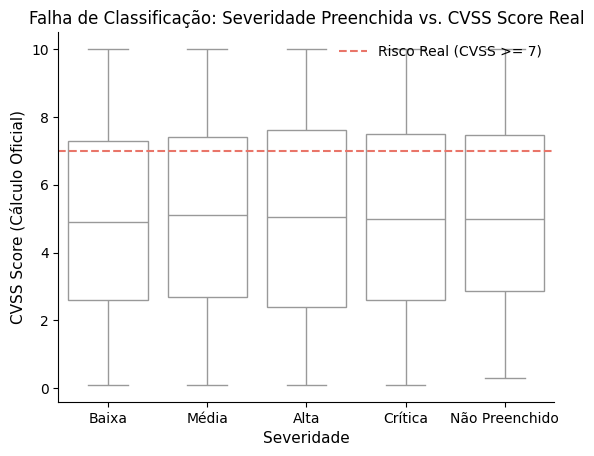

In [48]:
# 3. A Prova Visual (Boxplot limpo e ordenado)
sns.boxplot(
    data=df_vulnerabilidades, 
    x='severidade_normalizada', 
    y='cvss_score', 
    order=['Baixa', 'Média', 'Alta', 'Crítica', 'Não Preenchido'],
    color="white"
)

# Linha de corte do risco real
plt.axhline(y=7.0, color="#e97569", linestyle='--', label='Risco Real (CVSS >= 7)')

# Refinamento visual
sns.despine()
plt.title('Falha de Classificação: Severidade Preenchida vs. CVSS Score Real')
plt.xlabel('Severidade', fontsize=11)
plt.ylabel('CVSS Score (Cálculo Oficial)', fontsize=11)
plt.legend(frameon=False)

plt.show()

A análise revela um descolamento crítico entre a severidade qualitativa atribuída e a pontuação técnica (`cvss_score`). A presença de vulnerabilidades 'Baixas' com CVSS máximo (10.0) e 'Críticas' com CVSS quase nulo (0.1) evidencia que a regra de classificação de risco na origem falhou ou está sendo preenchida de forma arbitrária

### Tratamento de Datas
Aplicação de um filtro para identificar registros que fogem do formato padrão esperado, mapeando possíveis datas inválidas ou anomalias.

In [49]:
# 1. Filtro para data_abertura (ignora nulos e traz o que NÃO bate com o padrão)
datas_anomalas_data_abertura = df_vulnerabilidades[
    df_vulnerabilidades['data_abertura'].notnull() & 
    ~df_vulnerabilidades['data_abertura'].astype(str).str.match(r'^\d{2}/\d{2}/\d{4}$')
]

# 2. Filtro para data_correcao (ignora nulos e traz o que NÃO bate com o padrão)
datas_anomalas_data_correcao = df_vulnerabilidades[
    df_vulnerabilidades['data_correcao'].notnull() & 
    ~df_vulnerabilidades['data_correcao'].astype(str).str.match(r'^\d{2}/\d{2}/\d{4}$')
]

# 3. Listar quantas são e quais são os formatos diferentes
print(f"Total de registros de abertura com data fora do padrão: {len(datas_anomalas_data_abertura)}")
print(datas_anomalas_data_abertura['data_abertura'].unique(), "\n")

print(f"Total de registros de correção com data fora do padrão: {len(datas_anomalas_data_correcao)}")
print(datas_anomalas_data_correcao['data_correcao'].unique())

Total de registros de abertura com data fora do padrão: 56
['03-29-2026' '2026-13-01' '06-16-2026' '05-30-2026' '01-30-2026'
 '08-13-2026' '05-21-2026' '03-20-2026' '05-14-2026' '06-23-2026'
 '03-28-2026' '02-20-2026' '04-17-2026' '08-28-2026' '06-22-2026'
 '08-27-2026' '08-29-2026' '06-28-2026' '07-22-2026' '03-19-2026'
 '06-29-2026' '03-16-2026' '05-24-2026' '06-21-2026' '06-30-2026'
 '06-19-2026' '05-23-2026' '07-15-2026'] 

Total de registros de correção com data fora do padrão: 0
[]


Identificado 56 anomalias na formatação de `data_abertura`, causadas principalmente pela inversão entre dia e mês (formato americano MM-DD-YYYY). Esse mapeamento prévio direciona o tratamento via `datetime` com parâmetros específicos para evitar a corrupção da timeline

Conversão da coluna para o tipo datetime. Como há formatos variados, o parâmetro `format='mixed'` é utilizado. Registros totalmente inválidos serão convertidos para nulo (`NaT`).

In [50]:
# Conversão para datetime forçando erros para NaT (Not a Time)
# 1. Converter as datas para o formato datetime (lidando com os formatos mistos)
df_vulnerabilidades['data_abertura_dt'] = pd.to_datetime(df_vulnerabilidades['data_abertura'], format='mixed', dayfirst=True, errors='coerce')
df_vulnerabilidades['data_correcao_dt'] = pd.to_datetime(df_vulnerabilidades['data_correcao'], format='mixed', dayfirst=True, errors='coerce')

sla_vulnerabilidades = (df_vulnerabilidades[df_vulnerabilidades['data_correcao_dt'].notnull()]['data_correcao_dt'] - df_vulnerabilidades[df_vulnerabilidades['data_correcao_dt'].notnull()]['data_abertura_dt']).dt.days

sla_vulnerabilidades.describe()

count    461.000000
mean      47.720174
std       31.477767
min      -87.000000
25%       24.000000
50%       47.000000
75%       70.000000
max      230.000000
dtype: float64

A estatística descritiva identificou um erro lógico severo na base de dados: o SLA mínimo registra -87 dias. Isso aponta para falhas sistêmicas na origem da extração, onde a data de correção é registrada antes mesmo da abertura do chamado, exigindo a criação de uma flag de exclusão ou revisão para estes registros irreais

### Mapeamento de chaves e cardinalidade das entidades

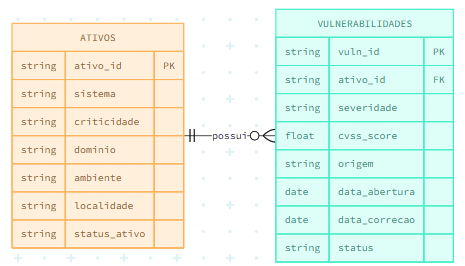

## Validação da Base Processada
Após a execução do script de tratamento, os arquivos processados são carregados para validação do resultado final.

In [51]:
df_ativos_limpo = pd.read_csv(r'..\data\processed\ativos_limpo.csv', sep=';') 
df_vulnerabilidades_limpo = pd.read_csv(r'..\data\processed\vulnerabilidades_limpo.csv', sep=';')

display(df_ativos_limpo)
display(df_vulnerabilidades_limpo)

,ativo_id,sistema,criticidade,dominio,ambiente,localidade,status_ativo
0,A0001,Sistema_1,Crítica,Dominio_2,Homologação,São Paulo,Em desativação
1,A0002,Sistema_2,Média,Dominio_3,Produção,São Paulo,Em desativação
2,A0003,Sistema_3,Média,Dominio_4,Homologação,São Paulo,Ativo
3,A0004,Sistema_4,Alta,Dominio_5,Homologação,Campinas,Ativo
4,A0005,Sistema_5,Alta,Dominio_6,Produção,Recife,Ativo
...,...,...,...,...,...,...,...
195,A0196,Sistema_196,Baixa,Dominio_5,Desenvolvimento,Recife,Ativo
196,A0197,Sistema_197,Alta,Dominio_6,Homologação,Curitiba,Ativo
197,A0198,Sistema_198,Baixa,Dominio_7,Desenvolvimento,São Paulo,Em desativação
198,A0199,Sistema_199,Crítica,Dominio_8,Homologação,Recife,Ativo


,vuln_id,ativo_id,severidade_corrigida,cvss_score,origem,status_vulnerabilidade,data_abertura,data_correcao,sistema,criticidade_ativo,ambiente,status_ativo,flag_ativo_orfao,flag_data_abertura_invalida,flag_data_correcao_futura,flag_erro_data_sla,dias_para_correcao
0,V00001,A0078,Baixa,2.8,Cloud Security,Em tratamento,2026-03-21,NaN,Sistema_78,Crítica,Homologação,Ativo,False,False,NaN,0,NaN
1,V00002,A0060,Alta,7.5,Qualys,Em tratamento,2026-06-01,NaN,Sistema_60,Média,Não Mapeado,Ativo,False,False,NaN,0,NaN
2,V00003,A0080,Baixa,1.7,Veracode,Aberta,2026-08-18,NaN,Sistema_80,Crítica,Produção,Ativo,False,False,NaN,0,NaN
3,V00004,A0086,Baixa,2.5,Qualys,Aberta,2026-06-16,NaN,Sistema_86,Média,Produção,Ativo,False,False,NaN,0,NaN
4,V00005,A0089,Média,4.4,Cloud Security,Em tratamento,2026-02-12,NaN,Sistema_89,Média,Produção,Ativo,False,False,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,V00101,A9999,Baixa,3.9,Cloud Security,Aceita,2026-06-08,NaN,Sistema Desconhecido,Não Mapeado,Ambiente Desconhecido,Desconhecido,True,False,NaN,0,NaN
1996,V00501,A9999,Média,4.7,Veracode,Em tratamento,2026-05-07,NaN,Sistema Desconhecido,Não Mapeado,Ambiente Desconhecido,Desconhecido,True,False,NaN,0,NaN
1997,V00901,A9999,Média,5.8,Cloud Security,Corrigida,2026-01-04,2026-03-29,Sistema Desconhecido,Não Mapeado,Ambiente Desconhecido,Desconhecido,True,False,False,0,84.0
1998,V01301,A9999,Alta,7.5,Cloud Security,Corrigida,2026-07-21,2026-09-23,Sistema Desconhecido,Não Mapeado,Ambiente Desconhecido,Desconhecido,True,False,False,0,64.0
